# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import copy

import model_ricard as m       # I've put all the functions in a separate Python file

In [2]:
# parameters of the simulation
par={'L': 4,                    # side length of the squared lattice
     'p_self_link': 0,         # probability for each cell of having a self link
     'C_density': 0.5,                       # initial density of links
     'J_range': [-1,+1],                       # define the possible value for J.
     'gamma': 2,
     'T_crossover_ratio': 0.1,                    # percentage of offspring to be generated by crossover + mutation (instead of only mutation)
     'target_set': [0.0,1.0,1.0,0.0],
     'input_set':[[0,0],[0,1],[1,0],[1,1]],
     'ff_iter': 4,                               # number of iterations the ff is executed for computing the output of a network (to reach the steady state)
     'state_bound': [-10,+10],                    # boundaries on the possibile values of the state
     'J_mutation_radius': 0.1,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.2,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 0.1,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.8,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'x_n': np.linspace(-1,1,64),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'n_iter': 400,
     'N_sol': 100}                       # number of solutions (individuals, networks) considered in the simulation

#nrd.seed(1234)

In [3]:
solutions, lmean, t_dist_mean, volume_mean = m.evolution(par,verb=3,gen_verb=False)

Iteration #0...
Mean loss: 0.5088528810523515
Mean target distance: 0.5088528801902625
Parents indexes: [[47 31]
 [56 12]
 [ 1 52]
 [56 57]
 [93 21]
 [80 91]
 [74 81]
 [14 57]
 [66 27]
 [69 22]
 [30 67]
 [42 38]
 [97 34]
 [ 2 84]
 [27 16]
 [73 62]
 [28 78]
 [86 33]
 [71 99]
 [ 5 27]
 [94  4]
 [95 14]
 [42 58]
 [65 77]
 [82 47]
 [85 33]
 [79 78]
 [43 58]
 [98 32]
 [45 61]
 [ 8 19]
 [65 28]
 [76  8]
 [67 25]
 [82 59]
 [91 14]
 [65 85]
 [80 54]
 [65 88]
 [78 43]]
Selection Probabilities: [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01]
I

In [4]:
print(f'# parents: {int(np.floor(par['N_sol'] * par['reproduction_ratio'])-np.floor(par['N_sol'] * par['reproduction_ratio'])%2)}')

# parents: 80


In [5]:
s = copy.deepcopy(solutions)
losses = []
for n,sol in enumerate(s[:20]):
    print(f'Solution #{n}')
    loss,_,_ = m.compute_loss(sol,par,verb=True)
    losses.append(loss)
    print(f'loss:{loss}')

Solution #0
Input: [0, 0] -> Output: -0.053827116402323405
Target distance:0.053827116402323405
Link cost:0.10748455472911239
Input: [0, 1] -> Output: -0.053828095729341774
Target distance:1.0538280957293418
Link cost:0.10748455472911239
Input: [1, 0] -> Output: -0.05380764209536448
Target distance:1.0538076420953644
Link cost:0.10748455472911239
Input: [1, 1] -> Output: -0.05380860604696169
Target distance:0.05380860604696169
Link cost:0.10748455472911239
loss:0.5538178650684978
Solution #1
Input: [0, 0] -> Output: 0.01652761558132876
Target distance:0.01652761558132876
Link cost:0.08792597750101347
Input: [0, 1] -> Output: 0.016527614467195306
Target distance:0.9834723855328047
Link cost:0.08792597750101347
Input: [1, 0] -> Output: 0.016527606019049568
Target distance:0.9834723939809504
Link cost:0.08792597750101347
Input: [1, 1] -> Output: 0.016527605208229046
Target distance:0.016527605208229046
Link cost:0.08792597750101347
loss:0.5000000000758282
Solution #2
Input: [0, 0] -> Outp

In [6]:
print(f'Mean final loss: {np.mean(np.array(losses) < 100)}')

Mean final loss: 1.0


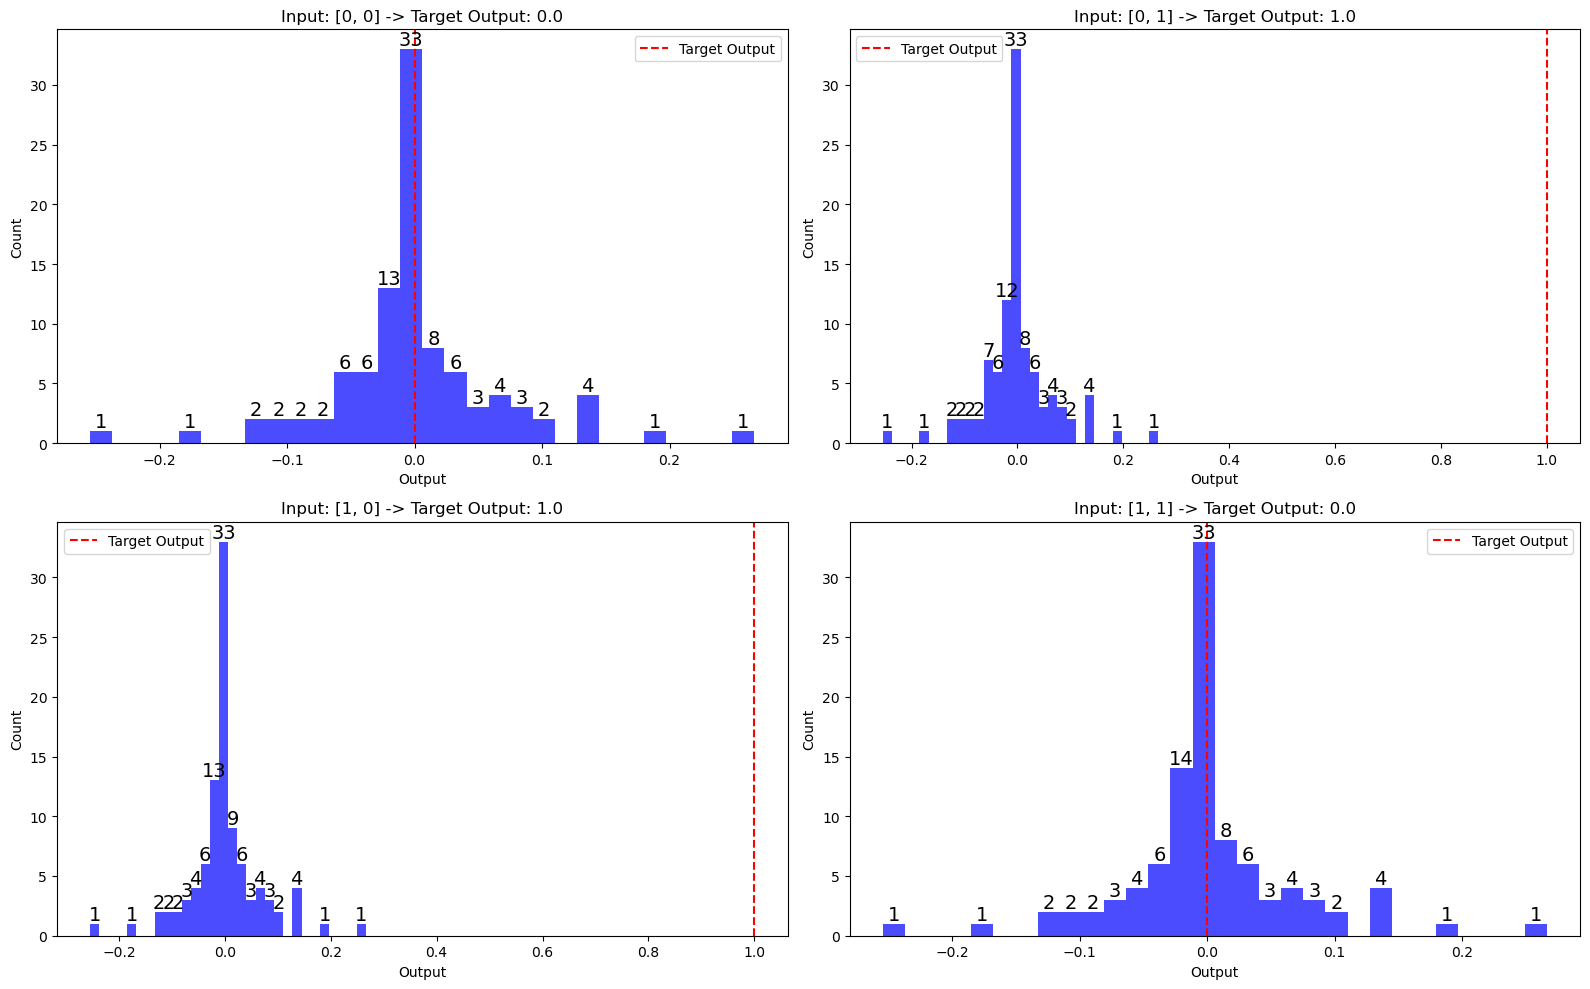

In [7]:
outputs = np.zeros((len(solutions),len(par['input_set'])))
for n,sol in enumerate(solutions):
    for i,input in enumerate(par['input_set']):
        output = m.ff(input,sol,par)
        outputs[n,i] = output

fig, axes = plt.subplots(2, len(par['input_set'])//2, figsize=(16, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.hist(outputs[:, i], bins=30, alpha=0.7, color='b')
    ax.set_title(f'Input: {par["input_set"][i]} -> Target Output: {par['target_set'][i]}')
    ax.set_xlabel('Output')
    ax.set_ylabel('Count')
    ax.axvline(par['target_set'][i], label='Target Output', color='r',linestyle='--')
    #ax.set_xticks(list(ax.get_xticks()) + [par['target_set'][i]])
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}', 
                        (patch.get_x() + patch.get_width() / 2, height), 
                        ha='center', va='bottom', fontsize=14)
    ax.legend()
plt.tight_layout()
plt.show()

In [8]:
print(f'Vertex numbers of inputs: 0,{(par['L'] - 1) * par['L']-1}')
print(f'Vertex numbers of the output: {par['L']**2-1}')

Vertex numbers of inputs: 0,11
Vertex numbers of the output: 15


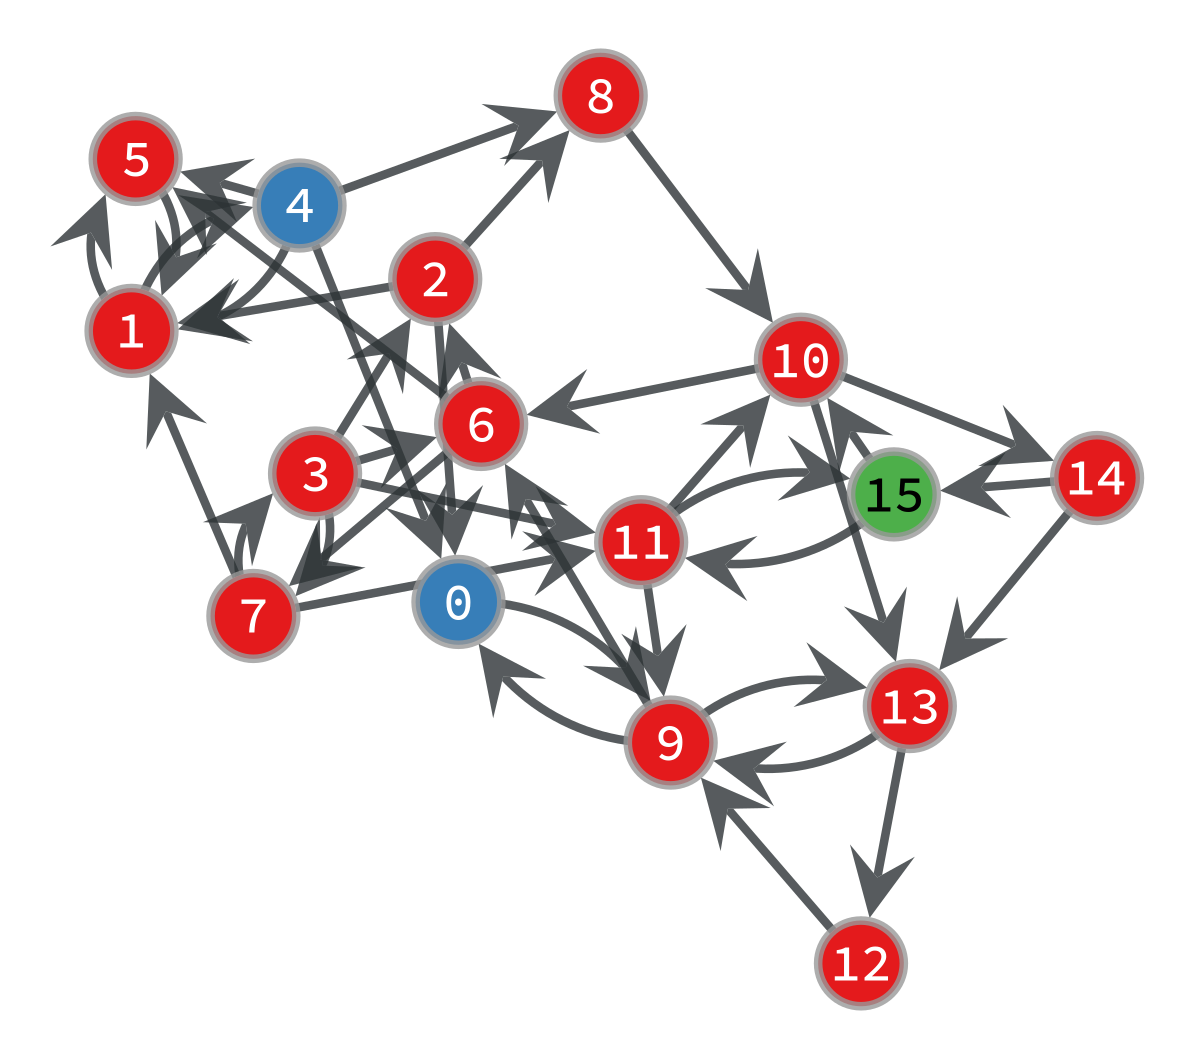

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7f8a8efc9310, at 0x7f8a8efe1e10>

In [9]:
graph = s[0].G

highlight = graph.new_vertex_property('int')
highlight[graph.vertex(0)] = 1
highlight[graph.vertex(par['L'])] = 1
highlight[graph.vertex(graph.num_vertices()-1)] = 2

graph_draw(
    graph,
    vertex_text=graph.vertex_index,
    vertex_fill_color=highlight,
    vcmap=plt.cm.Set1
)

In [10]:
print(f'Links density:{np.sum(s[0].C)/s[0].C.shape[0]**2}')

Links density:0.1484375


In [11]:
for input in par['input_set']:
    output,_ = m.ff(input,s[2],par,verb=2)
    print(f'Input:{input} -> Output:{output}')

Input:[0, 0] -> Output:-0.015356191173239275
Input:[0, 1] -> Output:-0.01535619117323861
Input:[1, 0] -> Output:-0.015356191173237943
Input:[1, 1] -> Output:-0.01535619117324094


In [12]:
def plot_T(g:float,par:dict) -> None:
    """Function to plot the shape of the transfer function given the Fourier coefficients.

    Args:
        T (np.ndarray): array of the Fourier coefficients of A SINGLE cell.
        par (dict): simulation parameters.
    """
    new_fun = lambda x: par['gamma'] / (1+np.exp(-g*x)) - par['gamma']/2
    x = np.linspace(-100,100,1000)
    plt.plot(x,new_fun(x))
    plt.grid()
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Transfer function')
    plt.show()
        

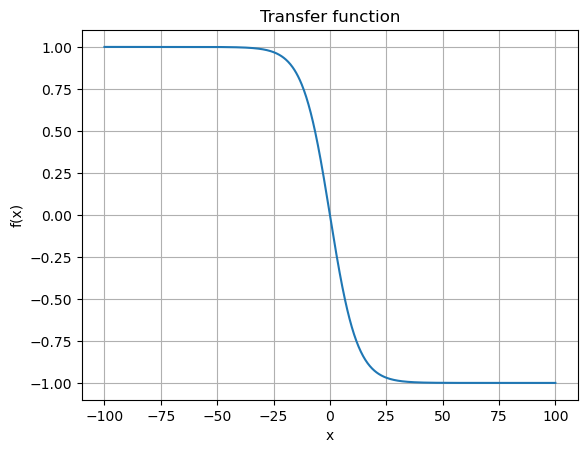

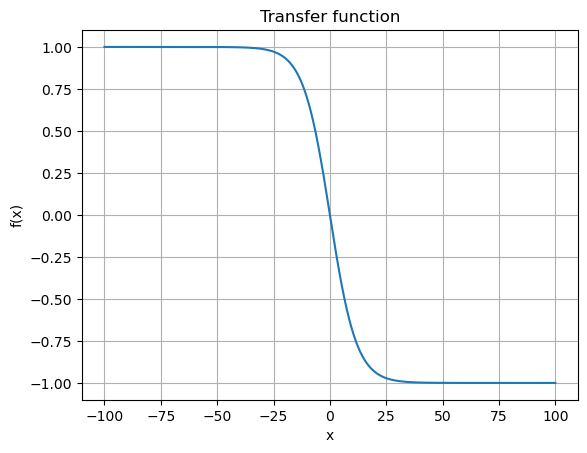

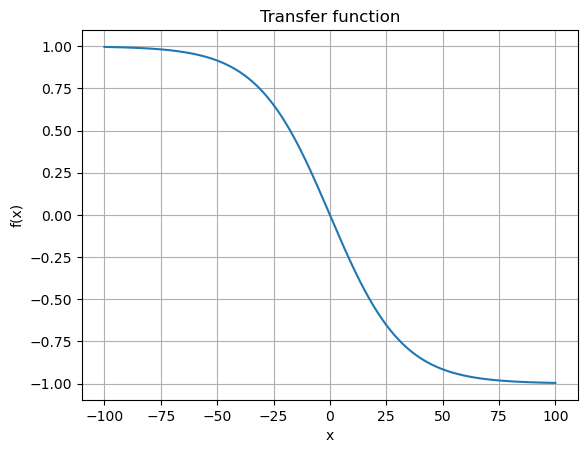

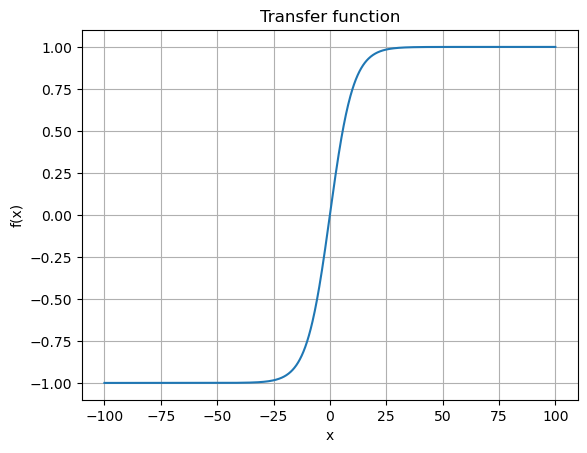

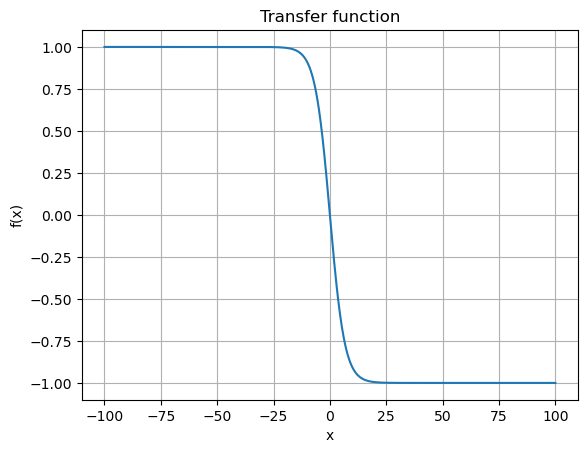

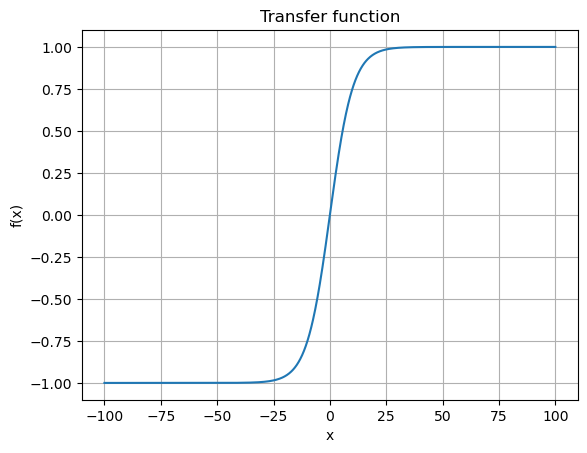

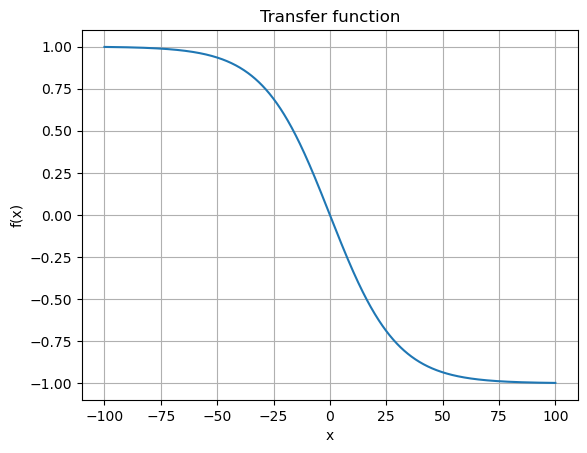

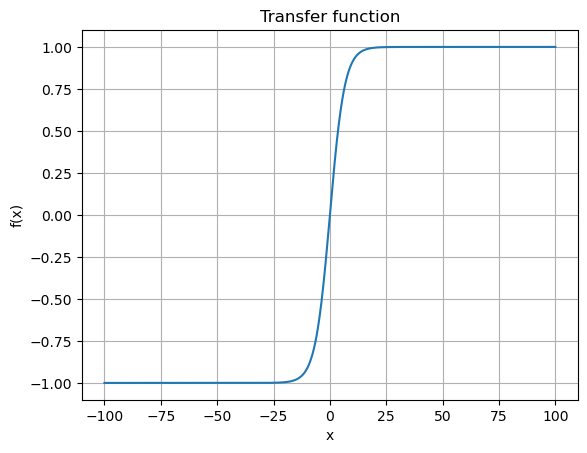

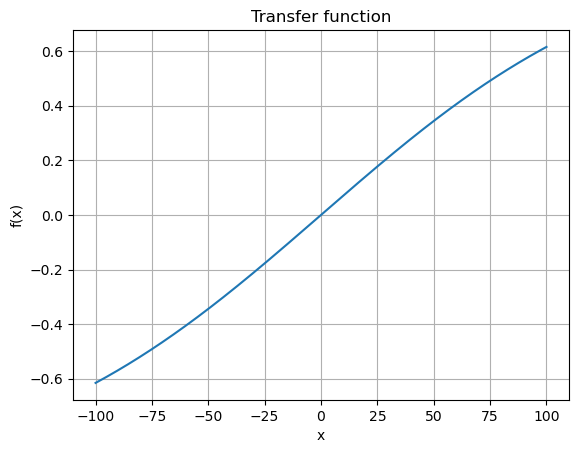

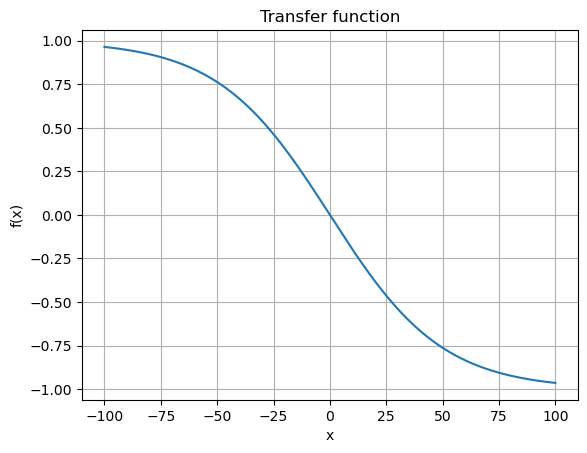

In [13]:
for i in range(10):
    plot_T(s[0].T[i],par)

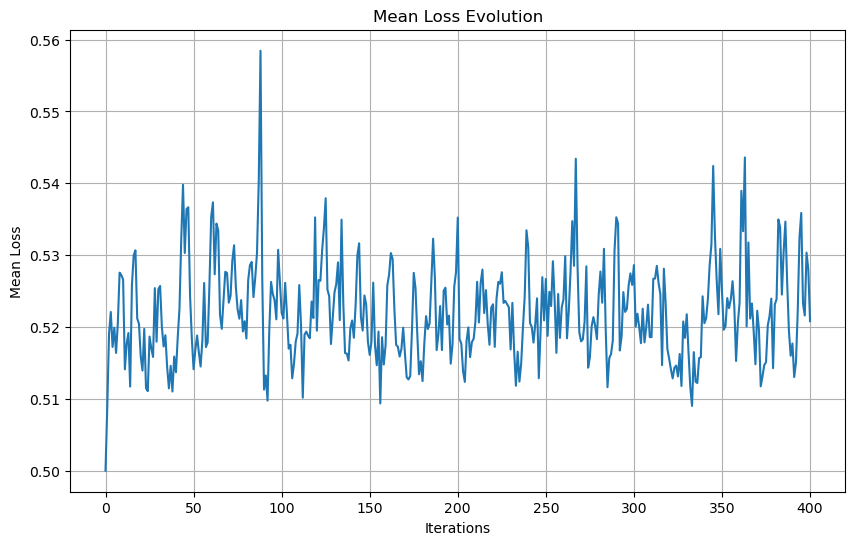

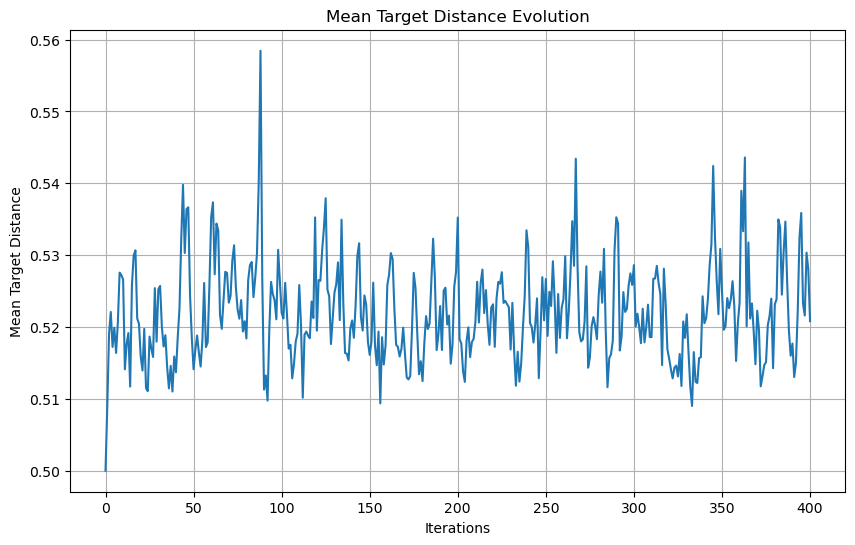

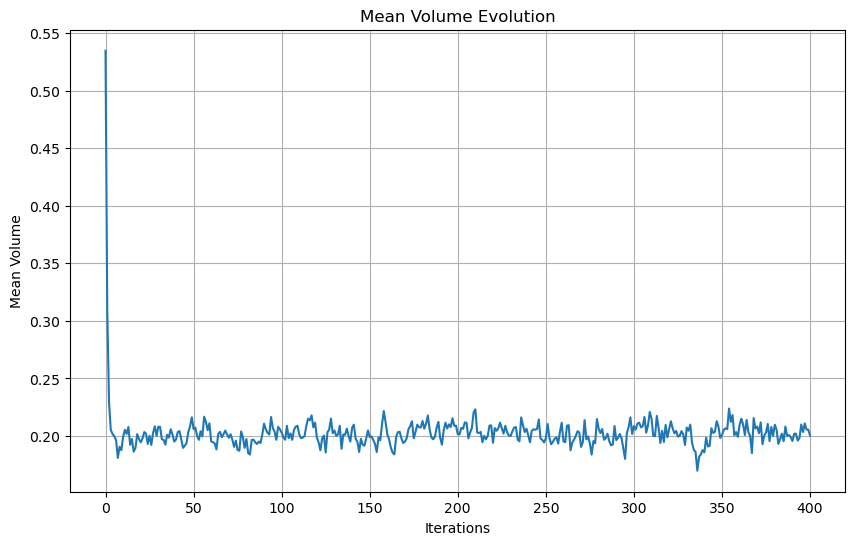

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(lmean)
plt.title('Mean Loss Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Loss')
#plt.yscale('log')
#plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t_dist_mean)
plt.title('Mean Target Distance Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Target Distance')
#plt.yscale('log')
#plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(volume_mean)
plt.title('Mean Volume Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Volume')
#plt.yscale('log')
#plt.xscale('log')
plt.grid(True)
plt.show()